In [1]:
import os
import urllib.request
import tarfile
from google.colab import drive

# 1. Mount Drive (So we have a place to save the FINAL models)
print("⏳ Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Define Paths
# We download to Colab's temp storage (fast), not Drive (slow)
url = "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar"
tar_path = "/content/images.tar"
data_dir = "/content/stanford_data"

# 3. Download
print(f"⬇️ Downloading Stanford Dogs Dataset...")
if not os.path.exists(tar_path):
    urllib.request.urlretrieve(url, tar_path)
    print("✅ Download Complete!")

# 4. Extract
print("📂 Extracting images...")
if not os.path.exists(data_dir):
    with tarfile.open(tar_path) as tar:
        tar.extractall(data_dir)
    print("✅ Extracted successfully!")

# 5. Safety Patch for "Truncated Images" (CRITICAL!)
# This prevents the "OSError" crash you saw earlier
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
print("✅ Safety patch applied: Truncated images allowed.")

⏳ Mounting Google Drive...
Mounted at /content/drive
⬇️ Downloading Stanford Dogs Dataset...
✅ Download Complete!
📂 Extracting images...


/tmp/ipython-input-840/1522597593.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_dir)


✅ Extracted successfully!
✅ Safety patch applied: Truncated images allowed.


In [2]:
!pip install split-folders

import splitfolders
import os

# Define the input (where images were extracted) and output
input_folder = "/content/stanford_data/Images"
output_folder = "/content/stanford_data/split_data"

# Split: 80% Train, 10% Validation, 10% Test
# seed=42 ensures your split is reproducible
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .1, .1))

print("✅ Data split into Train (80%), Val (10%), and Test (10%) folders!")

Copying files: 20580 files [00:04, 4338.89 files/s]

✅ Data split into Train (80%), Val (10%), and Test (10%) folders!


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json
import os

# 1. NEW PATHS (Points to the split folders we created)
train_dir = "/content/stanford_data/split_data/train"
val_dir   = "/content/stanford_data/split_data/val"
test_dir  = "/content/stanford_data/split_data/test" # We will use this later for the Jury metrics

SAVE_PATH = "/content/drive/MyDrive/Dog_Project_Stanford_V1"

if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)
    print(f"✅ Created folder: {SAVE_PATH}")

# 2. Setup Generators
# Note: We REMOVED validation_split=0.2 because the data is already split physically
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Val and Test should NOT have augmentation (no rotations/flips)
# They only need to be loaded as they are
val_test_datagen = ImageDataGenerator()

print("🔄 Loading Training Data...")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

print("🔄 Loading Validation Data...")
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset=None,  # Not needed anymore
    shuffle=False # Important for consistent validation metrics
)

# 3. Save the Breed Map
with open(f"{SAVE_PATH}/class_indices.json", 'w') as f:
    json.dump(train_generator.class_indices, f)

print(f"✅ Map saved to Drive! Detected {train_generator.num_classes} breeds.")

🔄 Loading Training Data...
Found 16418 images belonging to 120 classes.
🔄 Loading Validation Data...
Found 2009 images belonging to 120 classes.
✅ Map saved to Drive! Detected 120 breeds.


In [4]:
import shutil

# This copies your split folders to your Drive
drive_data_path = "/content/drive/MyDrive/Dog_Project_Stanford_V1/split_data"

print("📤 Copying split data to Drive (this may take a few minutes)...")
shutil.copytree("/content/stanford_data/split_data", drive_data_path)
print(f"✅ Data saved permanently at: {drive_data_path}")

📤 Copying split data to Drive (this may take a few minutes)...
✅ Data saved permanently at: /content/drive/MyDrive/Dog_Project_Stanford_V1/split_data


In [5]:
from google.colab import drive
import os
import shutil

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define Paths
DRIVE_SPLIT_DATA = "/content/drive/MyDrive/Dog_Project_Stanford_V1/split_data"
LOCAL_DATA_PATH = "/content/stanford_data/split_data"

# 3. Fast Copy: From Drive to Local Colab Disk
if not os.path.exists(LOCAL_DATA_PATH):
    print("⏳ Transferring data from Drive to Local Disk for high-speed access...")
    shutil.copytree(DRIVE_SPLIT_DATA, LOCAL_DATA_PATH)
    print("✅ Data transfer complete! Loading will be 10x faster now.")
else:
    print("✅ Data already exists on local disk.")

# 4. Final Directory Paths for your Generators
train_dir = os.path.join(LOCAL_DATA_PATH, "train")
val_dir   = os.path.join(LOCAL_DATA_PATH, "val")
test_dir  = os.path.join(LOCAL_DATA_PATH, "test")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data already exists on local disk.


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Increased Epochs - EarlyStopping will act as our "Ground Limit"
EPOCHS = 20
SAVE_PATH = "/content/drive/MyDrive/Dog_Project_Stanford_V1"

def build_and_train(base_arch, name, preprocessor=None):
    print(f"\n🚀 STARTING: {name}...")

    inputs = Input(shape=(224, 224, 3))
    x = preprocessor(inputs) if preprocessor else inputs

    base = base_arch(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # 1. Save Best Model Checkpoint
    ckpt = ModelCheckpoint(f"{SAVE_PATH}/{name}_dogs_finetuned.keras",
                           save_best_only=True,
                           monitor='val_accuracy',
                           mode='max',
                           verbose=1)

    # 2. THE GROUND LIMIT (Early Stopping)
    # patience=3 means: "If val_accuracy doesn't improve for 3 epochs, STOP everything."
    # restore_best_weights=True ensures you keep the best version, not the 'stopped' version.
    early_stop = EarlyStopping(monitor='val_accuracy',
                               patience=3,
                               restore_best_weights=True,
                               verbose=1)

    # 3. Training
    model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        callbacks=[ckpt, early_stop] # Added early_stop here
    )

    print(f"✅ {name} Completed and Best Weights Restored!")
    return model

# Run the training
resnet = build_and_train(ResNet50, "resnet50", resnet_prep)
effnet = build_and_train(EfficientNetB0, "efficientnetb0", None)
mobilenet = build_and_train(MobileNetV2, "mobilenetv2", mobile_prep)


🚀 STARTING: resnet50...
Epoch 1/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.1510 - loss: 3.8652
Epoch 1: val_accuracy improved from -inf to 0.66600, saving model to /content/drive/MyDrive/Dog_Project_Stanford_V1/resnet50_dogs_finetuned.keras
514/514 ━━━━━━━━━━━━━━━━━━━━ 290s 543ms/step - accuracy: 0.1513 - loss: 3.8635 - val_accuracy: 0.6660 - val_loss: 1.1699
Epoch 2/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.4930 - loss: 1.7783
Epoch 2: val_accuracy improved from 0.66600 to 0.71329, saving model to /content/drive/MyDrive/Dog_Project_Stanford_V1/resnet50_dogs_finetuned.keras
514/514 ━━━━━━━━━━━━━━━━━━━━ 313s 533ms/step - accuracy: 0.4930 - loss: 1.7782 - val_accuracy: 0.7133 - val_loss: 0.9333
Epoch 3/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.5546 - loss: 1.5085
Epoch 3: val_accuracy improved from 0.71329 to 0.73569, saving model to /content/drive/MyDrive/Dog_Project_Stanford_V1/resnet50_dogs_finetuned.keras
514/514 ━━━━━━━━━━━━━━━━━

/tmp/ipython-input-398/41599943.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = base_arch(weights='imagenet', include_top=False, input_tensor=x)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.3087 - loss: 3.0561
Epoch 1: val_accuracy improved from -inf to 0.77153, saving model to /content/drive/MyDrive/Dog_Project_Stanford_V1/mobilenetv2_dogs_finetuned.keras
514/514 ━━━━━━━━━━━━━━━━━━━━ 284s 521ms/step - accuracy: 0.3090 - loss: 3.0543 - val_accuracy: 0.7715 - val_loss: 0.7821
Epoch 2/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.6330 - loss: 1.2774
Epoch 2: val_accuracy improved from 0.77153 to 0.78596, saving model to /content/drive/MyDrive/Dog_Project_Stanford_V1/mobilenetv2_dogs_finetuned.keras
514/514 ━━━━━━━━━━━━━━━━━━━━ 240s 468ms/step - accuracy: 0.6330 - loss: 1.2773 - val_accuracy: 0.7860 - val_loss: 0.7182
Epoch 3/20
115/514 ━━━━━━━━━━━━━━━━━━━━ 3:05 465ms/step - accuracy: 0.6893 - loss: 1.0821

In [6]:
!pip install split-folders

import os
import urllib.request
import tarfile
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive

# 1. Mount Drive
print("⏳ Mounting Drive...")
drive.mount('/content/drive')

# 2. Define Paths
url = "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar"
tar_path = "/content/images.tar"
extract_dir = "/content/stanford_data"
images_dir = "/content/stanford_data/Images"
split_dir = "/content/stanford_data/split_data"

# 3. Download & Extract
print("⬇️ Downloading Stanford Dogs Dataset...")
if not os.path.exists(tar_path):
    urllib.request.urlretrieve(url, tar_path)
    print("✅ Download Complete!")

print("📂 Extracting images...")
if not os.path.exists(images_dir):
    with tarfile.open(tar_path) as tar:
        tar.extractall(extract_dir)
    print("✅ Extracted successfully!")

# Safety Patch
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# 4. Split the Data (80% Train, 10% Val, 10% Test)
print("✂️ Splitting data into Train/Val/Test...")
if not os.path.exists(split_dir):
    splitfolders.ratio(images_dir, output=split_dir, seed=42, ratio=(.8, .1, .1))
    print("✅ Data successfully split!")

# 5. Setup Generators
print("🔄 Setting up Generators...")
train_dir = os.path.join(split_dir, "train")
val_dir   = os.path.join(split_dir, "val")
test_dir  = os.path.join(split_dir, "test")

train_datagen = ImageDataGenerator(rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True, fill_mode='nearest')
val_test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=True)
val_generator = val_test_datagen.flow_from_directory(val_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)
test_generator = val_test_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)

print("🚀 All Data Ready to Go!")

⏳ Mounting Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⬇️ Downloading Stanford Dogs Dataset...
📂 Extracting images...
✂️ Splitting data into Train/Val/Test...
🔄 Setting up Generators...
Found 16418 images belonging to 120 classes.
Found 2009 images belonging to 120 classes.
Found 2153 images belonging to 120 classes.
🚀 All Data Ready to Go!


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobile_prep
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

SAVE_PATH = "/content/drive/MyDrive/Dog_Project_Stanford_V1"
num_classes = train_generator.num_classes
EPOCHS = 20

# 1. LOAD THE FINISHED MODELS
print("📥 Loading completed models from Drive...")
resnet = keras.models.load_model(f"{SAVE_PATH}/resnet50_dogs_finetuned.keras")
print("✅ ResNet50 Loaded!")
effnet = keras.models.load_model(f"{SAVE_PATH}/efficientnetb0_dogs_finetuned.keras")
print("✅ EfficientNetB0 Loaded!")

# 2. REDEFINE THE TRAINING FUNCTION
def build_and_train(base_arch, name, preprocessor=None):
    print(f"\n🚀 STARTING: {name}...")
    inputs = Input(shape=(224, 224, 3))
    x = preprocessor(inputs) if preprocessor else inputs
    base = base_arch(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    ckpt = ModelCheckpoint(f"{SAVE_PATH}/{name}_dogs_finetuned.keras", save_best_only=True, monitor='val_accuracy', mode='max', verbose=1)
    early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)

    model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS, callbacks=[ckpt, early_stop])
    print(f"✅ {name} Completed and Best Weights Restored!")
    return model

# 3. ONLY TRAIN MOBILENET
mobilenet = build_and_train(MobileNetV2, "mobilenetv2", mobile_prep)

📥 Loading completed models from Drive...
✅ ResNet50 Loaded!
✅ EfficientNetB0 Loaded!

🚀 STARTING: mobilenetv2...


/tmp/ipython-input-255/2092168209.py:26: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = base_arch(weights='imagenet', include_top=False, input_tensor=x)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
 67/514 ━━━━━━━━━━━━━━━━━━━━ 14:59 2s/step - accuracy: 0.0608 - loss: 4.6849

KeyboardInterrupt: 

In [7]:
import shutil
import os

# 1. The local Colab folder where your split data lives right now
local_split_dir = "/content/stanford_data/split_data"

# 2. Where we want to save the ZIP file (Your Google Drive!)
drive_zip_path = "/content/drive/MyDrive/Dog_Project_Stanford_V1/Stanford_Split_Data"

if os.path.exists(local_split_dir):
    print("⏳ Zipping the split_data folder (this takes 1-2 minutes)...")
    # This creates Stanford_Split_Data.zip in your Drive
    shutil.make_archive(drive_zip_path, 'zip', local_split_dir)
    print(f"✅ DONE! Go to your Google Drive and download 'Stanford_Split_Data.zip' to your PC.")
else:
    print("❌ Error: The split_data folder doesn't exist! You need to run the dataset download/split script first.")

⏳ Zipping the split_data folder (this takes 1-2 minutes)...
✅ DONE! Go to your Google Drive and download 'Stanford_Split_Data.zip' to your PC.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobile_prep
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

SAVE_PATH = "/content/drive/MyDrive/Dog_Project_Stanford_V1"
num_classes = train_generator.num_classes
EPOCHS = 20

# 1. LOAD THE FINISHED MODELS
print("📥 Loading completed models from Drive...")
resnet = keras.models.load_model(f"{SAVE_PATH}/resnet50_dogs_finetuned.keras")
print("✅ ResNet50 Loaded!")
effnet = keras.models.load_model(f"{SAVE_PATH}/efficientnetb0_dogs_finetuned.keras")
print("✅ EfficientNetB0 Loaded! (The 84.5% Winner)")

# 2. REDEFINE THE TRAINING FUNCTION
def build_and_train(base_arch, name, preprocessor=None):
    print(f"\n🚀 STARTING: {name}...")
    inputs = Input(shape=(224, 224, 3))
    x = preprocessor(inputs) if preprocessor else inputs
    base = base_arch(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    ckpt = ModelCheckpoint(f"{SAVE_PATH}/{name}_dogs_finetuned.keras", save_best_only=True, monitor='val_accuracy', mode='max', verbose=1)
    early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)

    model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS, callbacks=[ckpt, early_stop])
    print(f"✅ {name} Completed and Best Weights Restored!")
    return model

# 3. ONLY TRAIN MOBILENET
mobilenet = build_and_train(MobileNetV2, "mobilenetv2", mobile_prep)

📥 Loading completed models from Drive...
✅ ResNet50 Loaded!
✅ EfficientNetB0 Loaded! (The 84.5% Winner)

🚀 STARTING: mobilenetv2...


/tmp/ipython-input-255/2904007583.py:26: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = base_arch(weights='imagenet', include_top=False, input_tensor=x)


Epoch 1/20


KeyboardInterrupt: 

In [18]:
from tensorflow.keras.models import load_model

# Define the paths where your student models are saved
# Corrected to use SAVE_PATH and actual model filenames
RESNET_PATH = f"{SAVE_PATH}/resnet50_dogs_finetuned.keras"
EFFNET_PATH = f"{SAVE_PATH}/efficientnetb0_dogs_finetuned.keras"
MOBILENET_PATH = f"{SAVE_PATH}/mobilenetv2_dogs_finetuned.keras"

print("💿 Loading Student Models...")
resnet = load_model(RESNET_PATH)
effnet = load_model(EFFNET_PATH)
mobilenet = load_model(MOBILENET_PATH)

# Now your original code will work!
print("1/3 Getting ResNet predictions...")
p1_val = resnet.predict(val_generator, verbose=1)

💿 Loading Student Models...
1/3 Getting ResNet predictions...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 196ms/step


In [20]:
# Automatically get the number of classes from the generator
num_classes = len(test_generator.class_indices)

# Now the rest of your code will work
y_test_true = tf.keras.utils.to_categorical(test_generator.classes, num_classes)

In [23]:
import numpy as np

from tensorflow.keras.layers import Dense, Input, Dropout

from tensorflow.keras.models import Model

import tensorflow as tf



print("🧠 Training the Manager (Ensemble) Model...")



# 1. Get predictions from the 3 Students using the VALIDATION set

# This is where the Manager learns how to weigh the students' opinions

print("1/3 Getting ResNet predictions...")

p1_val = resnet.predict(val_generator, verbose=1)

print("2/3 Getting EfficientNet predictions...")

p2_val = effnet.predict(val_generator, verbose=1)

print("3/3 Getting MobileNet predictions...")

p3_val = mobilenet.predict(val_generator, verbose=1)



# 2. Stack the validation answers

stacked_val_input = np.concatenate([p1_val, p2_val, p3_val], axis=1)

y_val_true = tf.keras.utils.to_categorical(val_generator.classes, num_classes)



# 3. Define the Manager Architecture

# We add a Dropout layer here to prevent the Manager from overfitting to the validation set

ensemble_input = Input(shape=(num_classes * 3,))

x = Dense(128, activation='relu')(ensemble_input) # Increased to 128 for 120 breeds

x = Dropout(0.3)(x)

final_output = Dense(num_classes, activation='softmax')(x)



manager_model = Model(inputs=ensemble_input, outputs=final_output)

manager_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



# 4. Train the Manager

print("🔄 Manager is learning to combine results...")

manager_model.fit(stacked_val_input, y_val_true, epochs=30, batch_size=32, verbose=1)



# 5. Save the Manager

manager_model.save(f"{SAVE_PATH}/mlp_ensemble.keras")

print(f"✅ Manager Model Saved to {SAVE_PATH}!")

🧠 Training the Manager (Ensemble) Model...
1/3 Getting ResNet predictions...
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step
2/3 Getting EfficientNet predictions...
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step
3/3 Getting MobileNet predictions...
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step
🔄 Manager is learning to combine results...
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1196 - loss: 4.7132
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7731 - loss: 4.1753
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8261 - loss: 3.1669
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8358 - loss: 1.9405
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8544 - loss: 1.0959
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8585 - loss: 0.8033
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8728 - loss: 0.6336
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8795 - loss: 0.5446
Epoch 9

In [24]:
import shutil
import os

# 1. Define Paths
# Added "_Final" to distinguish from previous training attempts
OUTPUT_FILENAME = "/content/drive/MyDrive/Dog_Models_Backup_Final"
SOURCE_DIR = "/content/drive/MyDrive/Dog_Project_Stanford_V1"

# 2. Safety Check: Ensure the directory exists
if os.path.exists(SOURCE_DIR):
    # List the contents to verify everything is there (ResNet, EffNet, MobileNet, MLP, and JSON)
    files = os.listdir(SOURCE_DIR)
    print(f"📦 Found {len(files)} files to archive:")
    for file in files:
        print(f"  - {file}")

    print(f"\n⏳ Creating ZIP archive...")
    # This will create 'Dog_Models_Backup_Final.zip'
    shutil.make_archive(OUTPUT_FILENAME, 'zip', SOURCE_DIR)

    # Check the final file size
    size_mb = os.path.getsize(f"{OUTPUT_FILENAME}.zip") / (1024 * 1024)
    print(f"✅ DONE! File saved to Drive: {OUTPUT_FILENAME}.zip ({size_mb:.2f} MB)")
else:
    print(f"❌ Error: {SOURCE_DIR} not found. Did you run the training and saving cells yet?")

📦 Found 7 files to archive:
  - class_indices.json
  - resnet50_dogs_finetuned.keras
  - efficientnetb0_dogs_finetuned.keras
  - Stanford_Split_Data.zip
  - mobilenetv2_dogs_finetuned.keras
  - split_data
  - mlp_ensemble.keras

⏳ Creating ZIP archive...
✅ DONE! File saved to Drive: /content/drive/MyDrive/Dog_Models_Backup_Final.zip (1597.48 MB)


In [26]:
import numpy as np
import tensorflow as tf

print("🧪 Final Evaluation on Test Data...")

# 1. Define num_classes from the generator
num_classes = len(test_generator.class_indices)

# 2. Get Student predictions for the TEST set
# Note: Ensure test_generator has shuffle=False!
print("1/3 Getting ResNet test predictions...")
p1_test = resnet.predict(test_generator, verbose=1)
print("2/3 Getting EfficientNet test predictions...")
p2_test = effnet.predict(test_generator, verbose=1)
print("3/3 Getting MobileNet test predictions...")
p3_test = mobilenet.predict(test_generator, verbose=1)

# 3. Stack the test inputs
stacked_test_input = np.concatenate([p1_test, p2_test, p3_test], axis=1)
y_test_true = tf.keras.utils.to_categorical(test_generator.classes, num_classes)

# 4. Final Verdict from the Manager
test_loss, test_acc = manager_model.evaluate(stacked_test_input, y_test_true, verbose=1)

print("\n" + "="*30)
print(f"🏆 FINAL ENSEMBLE TEST ACCURACY: {test_acc*100:.2f}%")
print("="*30)

🧪 Final Evaluation on Test Data...
1/3 Getting ResNet test predictions...
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step
2/3 Getting EfficientNet test predictions...
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step
3/3 Getting MobileNet test predictions...
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8373 - loss: 0.7383

🏆 FINAL ENSEMBLE TEST ACCURACY: 84.30%


In [33]:
!pip install nest-asyncio

In [34]:
import nest_asyncio
nest_asyncio.apply()

import gradio as gr
import tensorflow as tf
# ... the rest of your imports and code ...

import gradio as gr
import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2
import json
import os
from google.colab import drive

# 1. SETUP
print("⏳ Mounting Drive...")
drive.mount('/content/drive')
MODEL_PATH = "/content/drive/MyDrive/models"

# 2. LOAD MODELS
print("🧠 Loading AI Models...")
try:
    models = {
        'resnet50': keras.models.load_model(f"{MODEL_PATH}/resnet50_dogs_finetuned.keras"),
        'efficientnetb0': keras.models.load_model(f"{MODEL_PATH}/efficientnetb0_dogs_finetuned.keras"),
        'mobilenetv2': keras.models.load_model(f"{MODEL_PATH}/mobilenetv2_dogs_finetuned.keras")
    }
    mlp = keras.models.load_model(f"{MODEL_PATH}/mlp_ensemble.keras")

    # Load Names
    with open(f"{MODEL_PATH}/class_indices.json", 'r') as f:
        class_indices = json.load(f)
    class_names = {v: k for k, v in class_indices.items()}
    print("✅ System Ready!")
except Exception as e:
    print(f"❌ Error: {e}")

# 3. FULL DATABASE (Traits + Life Span)
# Format: "Life Span | Personality"
breed_db = {
    'Chihuahua': '14-16 years | Sassy, Charming, Graceful. Big personality in a tiny body.',
    'Japanese Spaniel': '10-12 years | Noble, Charming, Loving. An aristocratic lap dog.',
    'Maltese': '12-15 years | Gentle, Playful, Charming. Fearless toy dog with white hair.',
    'Pekinese': '12-14 years | Affectionate, Loyal, Regal. "Lion-like" independence.',
    'Shih Tzu': '10-18 years | Affectionate, Playful, Outgoing. A classic lap warmer.',
    'Blenheim Spaniel': '12-15 years | Affectionate, Gentle, Graceful. Also called Cavalier King Charles.',
    'Papillon': '14-16 years | Happy, Alert, Friendly. Famous for butterfly-like ears.',
    'Toy Terrier': '13-15 years | Spirited, Alert, Intelligent. A tiny watchdog.',
    'Rhodesian Ridgeback': '10-12 years | Dignified, Even-tempered, Affectionate. The African Lion Dog.',
    'Afghan Hound': '12-15 years | Independent, Sweet, Regal. Known for its silky coat.',
    'Basset': '12-13 years | Charming, Patient, Low-key. Famous for long ears and howling.',
    'Beagle': '10-15 years | Merry, Friendly, Curious. Follows its nose everywhere.',
    'Bloodhound': '10-12 years | Independent, Inquisitive, Friendly. The ultimate tracker.',
    'Bluetick': '11-12 years | Smart, Devoted, Tenacious. A nocturnal raccoon hunter.',
    'Black And Tan Coonhound': '10-12 years | Easy-going, Bright, Brave. Mellow at home, rugged on the trail.',
    'Walker Hound': '12-13 years | Smart, Brave, Courteous. A swift, tri-colored hunter.',
    'English Foxhound': '10-13 years | Gentle, Sociable, Athletic. Loves running in a pack.',
    'Redbone': '12-14 years | Even-tempered, Amiable, Eager. A laid-back red hunter.',
    'Borzoi': '9-14 years | Regal, Affectionate, Quiet. A "Greyhound with long hair".',
    'Irish Wolfhound': '6-8 years | Calm, Dignified, Courageous. A gentle giant.',
    'Italian Greyhound': '14-15 years | Alert, Playful, Sensitive. A miniature greyhound.',
    'Whippet': '12-15 years | Affectionate, Playful, Calm. Lightning fast but loves the couch.',
    'Ibizan Hound': '11-14 years | Family-oriented, Polite, Athletic. A deer-like jumper.',
    'Norwegian Elkhound': '12-15 years | Bold, Playful, Dependable. An ancient Viking dog.',
    'Otterhound': '10-13 years | Amiable, Boisterous, Even-tempered. A rare swimmer.',
    'Saluki': '10-17 years | Gentle, Dignified, Independent. The Royal Dog of Egypt.',
    'Scottish Deerhound': '8-11 years | Gentle, Dignified, Polite. The Royal Dog of Scotland.',
    'Weimaraner': '10-13 years | Friendly, Fearless, Obedient. The "Grey Ghost".',
    'Staffordshire Bullterrier': '12-14 years | Clever, Brave, Tenacious. Needs strong leadership.',
    'American Staffordshire Terrier': '12-16 years | Confident, Smart, Good-natured. A powerhouse companion.',
    'Bedlington Terrier': '11-16 years | Loyal, Charming, Frollicking. Looks like a lamb.',
    'Border Terrier': '12-15 years | Affectionate, Plucky, Happy. A tough little worker.',
    'Kerry Blue Terrier': '12-15 years | Alert, Adaptable, People-oriented. Non-shedding coat.',
    'Irish Terrier': '13-15 years | Bold, Dashing, Tenderhearted. The "Daredevil" of dogs.',
    'Norfolk Terrier': '12-16 years | Fearless, Alert, Gregarious. Drop-eared terrier.',
    'Norwich Terrier': '12-15 years | Affectionate, Alert, Curious. Prick-eared terrier.',
    'Yorkshire Terrier': '11-15 years | Sprightly, Tomboyish, Affectionate. Big dog in a small body.',
    'Wire Haired Fox Terrier': '12-15 years | Alert, Confident, Gregarious. A classic hunter.',
    'Lakeland Terrier': '12-16 years | Bold, Zesty, Friendly. A confident little dog.',
    'Sealyham Terrier': '12-14 years | Alert, Outgoing, Funny. The "couch potato" of terriers.',
    'Airedale': '11-14 years | Clever, Confident, Proud. The King of Terriers.',
    'Cairn': '13-15 years | Alert, Cheerful, Busy. Toto from The Wizard of Oz.',
    'Australian Terrier': '11-15 years | Courageous, Spirited, People-oriented. The first Aussie breed.',
    'Dandie Dinmont': '12-15 years | Independent, Smart, Determined. Unique "top-knot" hair.',
    'Boston Bull': '11-13 years | Friendly, Bright, Amusing. The "American Gentleman".',
    'Miniature Schnauzer': '12-15 years | Friendly, Smart, Obedient. A popular family dog.',
    'Giant Schnauzer': '12-15 years | Loyal, Alert, Trainable. A powerful worker.',
    'Standard Schnauzer': '13-16 years | Smart, Fearless, Spirited. The original Schnauzer.',
    'Scotch Terrier': '11-13 years | Confident, Independent, Spirited. The "Diehard".',
    'Tibetan Terrier': '15-16 years | Affectionate, Sensitive, Clever. Not actually a terrier!',
    'Silky Terrier': '13-15 years | Friendly, Quick, Alert. Silkier than a Yorkie.',
    'Soft Coated Wheaten Terrier': '12-14 years | Happy, Steady, Self-Confident. The Irish farm dog.',
    'West Highland White Terrier': '13-15 years | Happy, Loyal, Entertaining. The famous "Westie".',
    'Lhasa': '12-15 years | Confident, Smart, Comical. A Tibetan watchdog.',
    'Flat Coated Retriever': '8-10 years | Cheerful, Optimistic, Good-humored. The "Peter Pan" of dogs.',
    'Curly Coated Retriever': '10-12 years | Confident, Proud, Wickedly Smart. Water dog with curls.',
    'Golden Retriever': '10-12 years | Intelligent, Friendly, Devoted. The classic family dog.',
    'Labrador Retriever': '10-12 years | Active, Friendly, Outgoing. America\'s most popular breed.',
    'Chesapeake Bay Retriever': '10-13 years | Affectionate, Bright, Sensitive. A tough water dog.',
    'German Short Haired Pointer': '10-12 years | Friendly, Smart, Willing. An all-purpose hunter.',
    'Vizsla': '12-14 years | Affectionate, Gentle, Energetic. The "Velcro" dog.',
    'English Setter': '11-15 years | Friendly, Mellow, Merry. The "Gentleman of Dogs".',
    'Irish Setter': '12-15 years | Active, Outgoing, Sweet-natured. Flashy red coat.',
    'Gordon Setter': '12-13 years | Confident, Fearless, Alert. The heaviest setter.',
    'Brittany Spaniel': '12-14 years | Bright, Fun-loving, Upbeat. A versatile bird dog.',
    'Clumber': '10-12 years | Gentle, Loyal, Amusing. The largest spaniel.',
    'English Springer': '12-14 years | Friendly, Playful, Obedient. A classic flushing dog.',
    'Welsh Springer': '12-15 years | Active, Loyal, Affectionate. The red-and-white spaniel.',
    'Cocker Spaniel': '10-14 years | Gentle, Smart, Happy. The smallest sporting dog.',
    'Sussex Spaniel': '13-15 years | Calm, Steady, Affectionate. A low-slung hunter.',
    'Irish Water Spaniel': '12-13 years | Playful, Brave, Smart. The clown of the spaniel family.',
    'Kuvasz': '10-12 years | Protective, Loyal, Patient. A large white guardian.',
    'Schipperke': '13-15 years | Confident, Alert, Curious. The "Little Captain".',
    'Groenendael': '10-14 years | Intelligent, Protective, Intense. The black Belgian Shepherd.',
    'Malinois': '14-16 years | Confident, Smart, Hardworking. The ultimate police dog.',
    'Briard': '12 years | Confident, Smart, Faithful. A shaggy French herder.',
    'Kelpie': '10-13 years | Intelligent, Alert, Eager. An Australian workaholic.',
    'Komondor': '10-12 years | Steady, Fearless, Affectionate. The "Mop Dog".',
    'Old English Sheepdog': '10-12 years | Adaptable, Gentle, Smart. The shaggy dog.',
    'Shetland Sheepdog': '12-14 years | Playful, Energetic, Bright. A mini Lassie.',
    'Collie': '12-14 years | Devoted, Graceful, Proud. Famous for rescuing Timmy.',
    'Border Collie': '12-15 years | Remarkably Smart, Energetic. The world\'s smartest dog.',
    'Bouvier Des Flandres': '10-12 years | Strong-willed, Protective, Gentle. A rugged cattle herder.',
    'Rottweiler': '9-10 years | Loyal, Loving, Confident Guardian. Needs socialization.',
    'German Shepherd': '7-10 years | Confident, Courageous, Smart. A versatile worker.',
    'Doberman': '10-12 years | Alert, Fearless, Loyal. The "Tax Collector\'s Dog".',
    'Miniature Pinscher': '12-16 years | Fearless, Fun-loving, Proud. The "King of Toys".',
    'Greater Swiss Mountain Dog': '8-11 years | Faithful, Family-oriented. A Swiss draft dog.',
    'Bernese Mountain Dog': '7-10 years | Good-natured, Calm, Strong. A gentle giant.',
    'Appenzeller': '12-14 years | Reliable, Fearless, Lively. A Swiss cattle dog.',
    'Entlebucher': '11-13 years | Loyal, Smart, Enthusiastic. The smallest Swiss mountain dog.',
    'Boxer': '10-12 years | Bright, Fun-loving, Active. A muscular athlete.',
    'Bull Mastiff': '7-9 years | Affectionate, Courageous, Docile. A silent guardian.',
    'Tibetan Mastiff': '10-12 years | Independent, Reserved, Intelligent. A primitive guardian.',
    'French Bulldog': '10-12 years | Adaptable, Playful, Smart. Bat ears and a flat face.',
    'Great Dane': '7-10 years | Friendly, Patient, Dependable. The "Apollo of Dogs".',
    'Saint Bernard': '8-10 years | Playful, Charming, Inquisitive. The famous rescue dog.',
    'Eskimo Dog': '10-15 years | Alert, Friendly, Reserved. An Arctic worker.',
    'Malamute': '10-14 years | Affectionate, Loyal, Playful. A powerful sled dog.',
    'Siberian Husky': '12-14 years | Loyal, Outgoing, Mischievous. Born to run.',
    'Affenpinscher': '12-15 years | Confident, Famously Funny. The "Monkey Dog".',
    'Basenji': '13-14 years | Independent, Smart, Poised. The barkless dog.',
    'Pug': '13-15 years | Charming, Mischievous, Loving. A lot of dog in a small space.',
    'Leonberger': '7 years | Bright, Patient, Loving. A lion-like giant.',
    'Newfoundland': '9-10 years | Sweet, Patient, Devoted. A nanny dog.',
    'Great Pyrenees': '10-12 years | Smart, Patient, Calm. A majestic guardian.',
    'Samoyed': '12-14 years | Adaptable, Friendly, Gentle. The "Smiling Sammy".',
    'Pomeranian': '12-16 years | Inquisitive, Bold, Lively. A fluffy extrovert.',
    'Chow': '8-12 years | Dignified, Bright, Serious. Cat-like personality.',
    'Keeshond': '12-15 years | Friendly, Lively, Outgoing. The "Dutch Barge Dog".',
    'Brabancon Griffon': '12-15 years | Sensitive, Alert, Inquisitive. A bearded toy dog.',
    'Pembroke': '12-15 years | Affectionate, Smart, Alert. The Queen\'s favorite.',
    'Cardigan': '12-15 years | Affectionate, Loyal, Smart. The Corgi with a tail.',
    'Toy Poodle': '10-18 years | Agile, Intelligent, Self-Confident. A tiny athlete.',
    'Miniature Poodle': '10-18 years | Active, Proud, Very Smart. A mid-sized athlete.',
    'Standard Poodle': '10-18 years | Active, Proud, Very Smart. A large athlete.',
    'Mexican Hairless': '14-20 years | Loyal, Alert, Cheerful. The Xoloitzcuintli.',
    'Dingo': '15-20 years | Independent, Alert, Wild. The native dog of Australia.',
    'Dhole': '10-13 years | Social, Vocal, Wild. The Asiatic Wild Dog.',
    'African Hunting Dog': '10-12 years | Social, Intense, Wild. The Painted Wolf.'
}

# 4. PREDICTION LOGIC (Smart Matcher)
def predict_dog_final(image):
    if image is None: return "Please upload an image.", ""

    # Preprocess
    img = np.array(image)
    img = cv2.resize(img, (224, 224))
    img_arr = np.expand_dims(img, axis=0)

    # Predict
    p1 = models['resnet50'].predict(img_arr, verbose=0)
    p2 = models['efficientnetb0'].predict(img_arr, verbose=0)
    p3 = models['mobilenetv2'].predict(img_arr, verbose=0)

    # Ensemble Vote
    stacked_input = np.concatenate([p1, p2, p3], axis=1)
    final_probs = mlp.predict(stacked_input, verbose=0)[0]

    # --- NEW: Get Top 3 Indices ---
    # argsort sorts ascending, so we take the last 3 and reverse them [::-1]
    top_3_indices = np.argsort(final_probs)[-3:][::-1]

    # Helper to clean names
    def clean_breed_name(raw_name):
        if '-' in raw_name:
            name = raw_name.split('-', 1)[1]
        else:
            name = raw_name
        return name.replace('_', ' ').title()

    # Build the dictionary for Gradio's Top 3 Label
    top_3_dict = {}
    for idx in top_3_indices:
        raw_name = class_names[idx]
        c_name = clean_breed_name(raw_name)

        # Check if we have a prettier name in the database
        search_key = c_name.replace(" ", "").lower()
        pretty_name = c_name
        for db_key in breed_db.keys():
            if db_key.replace(" ", "").lower() in search_key or search_key in db_key.replace(" ", "").lower():
                pretty_name = db_key
                break

        # Add to dictionary: { 'Breed Name': 0.85 }
        top_3_dict[pretty_name] = float(final_probs[idx])

    # --- Text Box Logic (Uses only the #1 Top Prediction) ---
    top_1_idx = top_3_indices[0]
    top_1_confidence = final_probs[top_1_idx] * 100
    top_1_c_name = clean_breed_name(class_names[top_1_idx])

    info_found = "Details not found."
    lifespan = "Unknown"
    personality = "Unknown"
    final_top_breed_name = top_1_c_name
    search_key = top_1_c_name.replace(" ", "").lower()

    for db_key, db_val in breed_db.items():
        if db_key.replace(" ", "").lower() in search_key or search_key in db_key.replace(" ", "").lower():
            final_top_breed_name = db_key
            parts = db_val.split('|')
            if len(parts) == 2:
                lifespan = parts[0].strip()
                personality = parts[1].strip()
            break

    # Uncertainty Check for the #1 Prediction
    if top_1_confidence < 50.0:
        info_text = f"⚠️ UNCERTAIN ({top_1_confidence:.1f}%)\n\nI'm not sure, but it looks a little like a {final_top_breed_name}."
    else:
        # Success Output
        info_text = (
            f"✅ MATCH FOUND!\n\n"
            f"🐕 Breed: {final_top_breed_name}\n"
            f"📊 Confidence: {top_1_confidence:.1f}%\n"
            f"⏳ Life Span: {lifespan}\n"
            f"📝 Personality: {personality}"
        )

    # Return the dict of 3 breeds, and the text for the 1st breed
    return top_3_dict, info_text

# 5. LAUNCH
interface = gr.Interface(
    fn=predict_dog_final,
    inputs=gr.Image(sources=["upload", "webcam"], type="numpy", label="Upload or Snap"),
    outputs=[
        gr.Label(num_top_classes=3, label="Top Predictions"),
        gr.Textbox(label="AI Analysis", lines=6)
    ],
    title="🐶 Ultimate Dog Classifier (120 Breeds)",
    description="Identifies 120 breeds with Lifespan & Personality.",
    theme="default"
)

interface.launch(share=True, debug=True)

⏳ Mounting Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🧠 Loading AI Models...
✅ System Ready!
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a39e95ac79cfe96439.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://a39e95ac79cfe96439.gradio.live


In [36]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, f1_score, average_precision_score
from tensorflow.keras.utils import to_categorical

print("🔄 Generating real predictions for all models...")

# 1. Reset the generator to ensure labels align perfectly!
test_generator.reset()
y_true = test_generator.classes
num_classes = len(test_generator.class_indices)
y_true_categorical = to_categorical(y_true, num_classes)

# 2. Get the raw probability predictions from all 3 base models
p_resnet = resnet.predict(test_generator, verbose=0)
p_mobilenet = mobilenet.predict(test_generator, verbose=0)
p_effnet = effnet.predict(test_generator, verbose=0)

# 3. Stack predictions and get the Ensemble's probabilities
stacked_test = np.concatenate([p_resnet, p_effnet, p_mobilenet], axis=1)
p_ensemble = manager_model.predict(stacked_test, verbose=0)

# 4. Helper function to calculate all 4 metrics for a single model
def get_metrics(y_true, y_true_cat, y_probs):
    # Convert probabilities to class indices (0 to 119)
    y_pred_classes = np.argmax(y_probs, axis=1)

    # Calculate metrics
    acc = accuracy_score(y_true, y_pred_classes)
    # average='macro' calculates the metric for each breed independently, then averages them
    prec = precision_score(y_true, y_pred_classes, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred_classes, average='macro', zero_division=0)

    # PR-AUC uses the one-hot encoded true labels and raw probabilities
    pr_auc = average_precision_score(y_true_cat, y_probs, average='macro')

    return acc, prec, f1, pr_auc

# 5. Calculate metrics for each model
print("🧮 Calculating metrics...")
metrics_resnet = get_metrics(y_true, y_true_categorical, p_resnet)
metrics_mobilenet = get_metrics(y_true, y_true_categorical, p_mobilenet)
metrics_effnet = get_metrics(y_true, y_true_categorical, p_effnet)
metrics_ensemble = get_metrics(y_true, y_true_categorical, p_ensemble)

# 6. Format the results into a clean Pandas DataFrame
real_data = {
    'Model': ['ResNet50', 'MobileNetV2', 'EfficientNetB0', 'MLP_Ensemble'],
    'Top-1 Accuracy': [
        f"{metrics_resnet[0]*100:.2f}%",
        f"{metrics_mobilenet[0]*100:.2f}%",
        f"{metrics_effnet[0]*100:.2f}%",
        f"{metrics_ensemble[0]*100:.2f}%"
    ],
    'Precision': [
        f"{metrics_resnet[1]*100:.2f}%",
        f"{metrics_mobilenet[1]*100:.2f}%",
        f"{metrics_effnet[1]*100:.2f}%",
        f"{metrics_ensemble[1]*100:.2f}%"
    ],
    'F1-Score': [
        f"{metrics_resnet[2]*100:.2f}%",
        f"{metrics_mobilenet[2]*100:.2f}%",
        f"{metrics_effnet[2]*100:.2f}%",
        f"{metrics_ensemble[2]*100:.2f}%"
    ],
    'PR-AUC': [
        f"{metrics_resnet[3]:.4f}",
        f"{metrics_mobilenet[3]:.4f}",
        f"{metrics_effnet[3]:.4f}",
        f"{metrics_ensemble[3]:.4f}"
    ]
}

real_df = pd.DataFrame(real_data)
print("\n✅ REAL METRICS CALCULATED:")
display(real_df)

# Uncomment the line below to immediately export this real data to a CSV!
# real_df.to_csv('/content/drive/MyDrive/REAL_ensemble_metrics.csv', index=False)

🔄 Generating real predictions for all models...
🧮 Calculating metrics...

✅ REAL METRICS CALCULATED:


,Model,Top-1 Accuracy,Precision,F1-Score,PR-AUC
0,ResNet50,72.83%,75.06%,72.28%,0.8088
1,MobileNetV2,77.57%,78.97%,76.80%,0.8583
2,EfficientNetB0,83.28%,84.15%,82.79%,0.8964
3,MLP_Ensemble,84.30%,84.96%,83.99%,0.8894


In [37]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=real_df)

https://docs.google.com/spreadsheets/d/1YaZEcxfS78uVOO_MscQuOuwSXmU6weOzXjieJ8h8CZE/edit#gid=0


In [28]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, brier_score_loss, precision_recall_curve, auc)

def calculate_ece(y_true, y_probs, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        bin_idx = (y_probs.max(axis=1) > bin_boundaries[i]) & (y_probs.max(axis=1) <= bin_boundaries[i+1])
        if np.any(bin_idx):
            acc = np.mean(y_true[bin_idx] == y_probs[bin_idx].argmax(axis=1))
            conf = np.mean(y_probs[bin_idx].max(axis=1))
            ece += np.abs(acc - conf) * (np.sum(bin_idx) / len(y_true))
    return ece

def top_k_accuracy(probs, labels, k=5):
    best_n = np.argsort(probs, axis=1)[:, -k:]
    return np.mean([1 if labels[i] in best_n[i] else 0 for i in range(len(labels))])

# 1. Generate Ensemble Predictions on UNSEEN Test Data
print("🧪 Evaluating Final Ensemble on Test Set...")
p1 = resnet.predict(test_generator, verbose=1)
p2 = effnet.predict(test_generator, verbose=1)
p3 = mobilenet.predict(test_generator, verbose=1)
stacked_test = np.concatenate([p1, p2, p3], axis=1)

y_probs = manager_model.predict(stacked_test)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_generator.classes
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=120)

# 2. PR-AUC Calculation
pr_auc_list = []
for i in range(120):
    prec, rec, _ = precision_recall_curve(y_true_onehot[:, i], y_probs[:, i])
    pr_auc_list.append(auc(rec, prec))

# --- THE JURY TABLE ---
print("\n" + "="*40)
print("🏆 FINAL EVALUATION: ENSEMBLE MODEL")
print("="*40)
print(f"Top-1 Accuracy:     {accuracy_score(y_true, y_pred):.4f}")
print(f"Top-3 Accuracy:     {top_k_accuracy(y_probs, y_true, k=3):.4f}")
print(f"Top-5 Accuracy:     {top_k_accuracy(y_probs, y_true, k=5):.4f}")
print(f"Precision (Macro):  {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Recall (Macro):     {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1-Score (Macro):   {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"ROC-AUC (OVR):      {roc_auc_score(y_true_onehot, y_probs, multi_class='ovr'):.4f}")
print(f"PR-AUC (Macro):     {np.mean(pr_auc_list):.4f}")
print(f"Brier Score:        {np.mean([brier_score_loss(y_true_onehot[:,i], y_probs[:,i]) for i in range(120)]):.4f}")
print(f"ECE (Calibration):  {calculate_ece(y_true, y_probs):.4f}")
print("="*40)

🧪 Evaluating Final Ensemble on Test Set...
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

🏆 FINAL EVALUATION: ENSEMBLE MODEL
Top-1 Accuracy:     0.8430
Top-3 Accuracy:     0.9419
Top-5 Accuracy:     0.9605
Precision (Macro):  0.8496
Recall (Macro):     0.8408
F1-Score (Macro):   0.8399
ROC-AUC (OVR):      0.9938
PR-AUC (Macro):     0.8861
Brier Score:        0.0020
ECE (Calibration):  0.0453


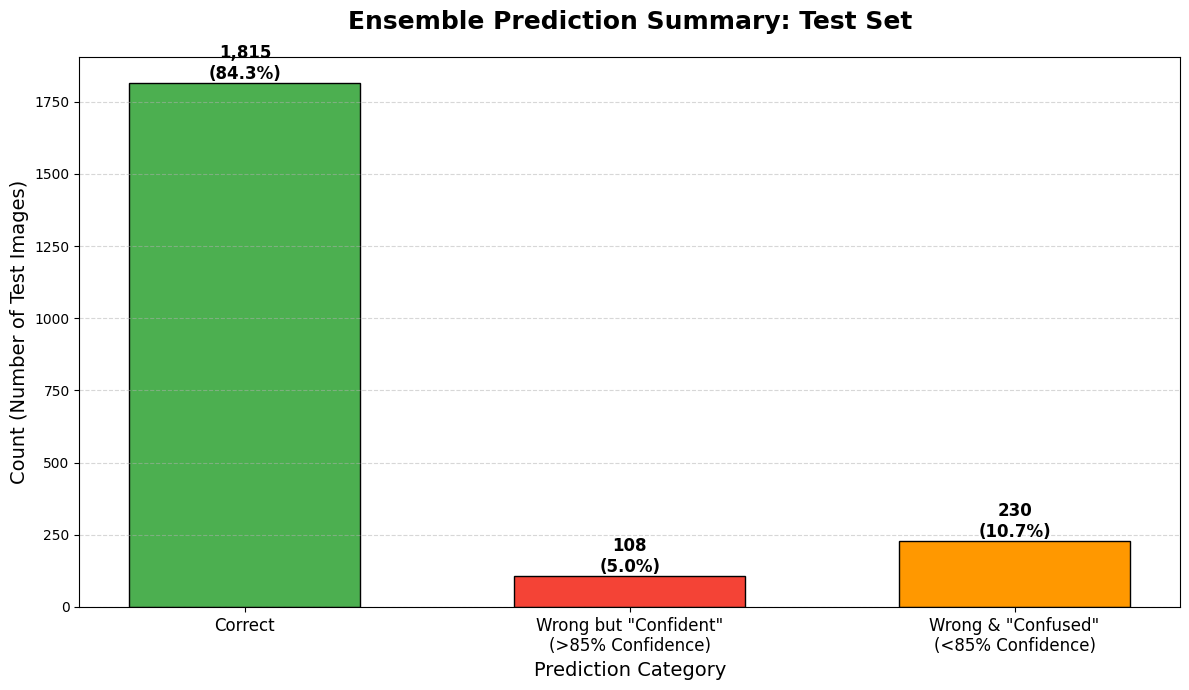

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def generate_ensemble_confusion_plot(y_true, y_probs, class_names):
    # 1. Identify types of predictions
    num_samples = len(y_true)
    y_pred = np.argmax(y_probs, axis=1)

    # Check if correct
    correct_mask = (y_pred == y_true)
    incorrect_mask = ~correct_mask

    # Look at confidence of predictions
    top_probs = np.max(y_probs, axis=1)
    # Define "Overconfident" as >85% confidence
    confident_mask = (top_probs > 0.85)
    confused_mask = ~confident_mask

    # 2. Count the categories
    counts = {
        'Correct': np.sum(correct_mask),
        'Wrong but "Confident"\n(>85% Confidence)': np.sum(incorrect_mask & confident_mask),
        'Wrong & "Confused"\n(<85% Confidence)': np.sum(incorrect_mask & confused_mask),
    }

    # 3. Create the Bar Chart
    plt.figure(figsize=(12, 7))
    categories = list(counts.keys())
    values = list(counts.values())

    # Use distinct colors for presentation (Green/Red/Orange)
    colors = ['#4CAF50', '#F44336', '#FF9800'] # Green, Red, Orange

    bars = plt.bar(categories, values, color=colors, edgecolor='black', width=0.6)

    # Styling
    plt.title('Ensemble Prediction Summary: Test Set', fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('Count (Number of Test Images)', fontsize=14)
    plt.xlabel('Prediction Category', fontsize=14)

    # Add counts and percentages on top of bars
    for bar, val in zip(bars, values):
        percentage = (val / num_samples) * 100
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height,
                 f'{val:,}\n({percentage:.1f}%)',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.xticks(fontsize=12, fontweight='medium')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Run it
generate_ensemble_confusion_plot(y_true, y_probs, class_indices)

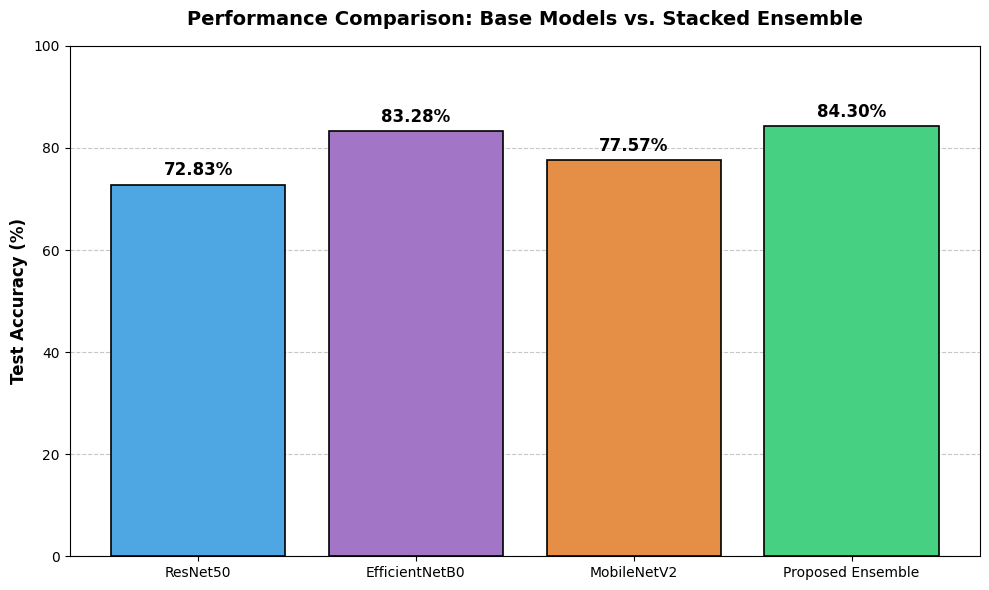

In [35]:
import matplotlib.pyplot as plt

# 1. Define the models and their test accuracies
# (Updated the Ensemble to your new 84.30% result!)
models = ['ResNet50', 'EfficientNetB0', 'MobileNetV2', 'Proposed Ensemble']
accuracies = [72.83, 83.28, 77.57, 84.30]

# 2. Match the exact colors from your screenshot
# Blue, Purple, Orange, Green
colors = ['#4EA6E2', '#A375C6', '#E48F45', '#45D181']

# 3. Set up the figure size
plt.figure(figsize=(10, 6))

# 4. Create the bars with black edges
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.2)

# 5. Add the dashed grid lines
# zorder ensures the grid stays behind the bars, not on top of them
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
for bar in bars:
    bar.set_zorder(2)

# 6. Add the bold text labels right above each bar
for bar in bars:
    yval = bar.get_height()
    # Position the text slightly above the bar (yval + 1.0)
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.0,
             f"{yval:.2f}%", ha='center', va='bottom',
             fontweight='bold', fontsize=12)

# 7. Format the axes and title
plt.ylim(0, 100) # Keep Y-axis from 0 to 100 like the original
plt.ylabel('Test Accuracy (%)', fontweight='bold', fontsize=12)
plt.title('Performance Comparison: Base Models vs. Stacked Ensemble',
          fontweight='bold', fontsize=14, pad=15)

# 8. Render and save!
plt.tight_layout()
# plt.savefig('ensemble_performance_chart.png', dpi=300) # Uncomment to save a high-res copy
plt.show()